In [142]:
import numpy as np
import matplotlib.pyplot as plt

import sys
import os

sys.path.append(os.path.abspath('..'))

from algorithms.auxiliares import *

# Datos XOR

In [143]:
ruta_data = os.path.abspath('../data')

X_train, y_train = cargar_datos_csv(os.path.join(ruta_data, 'XOR_trn.csv'))
X_test, y_test = cargar_datos_csv(os.path.join(ruta_data, 'XOR_tst.csv'))
X_train, y_train, X_test, y_test = np.array(X_train), np.array(y_train), np.array(X_test), np.array(y_test)

y_train_ravel = y_train.ravel()
y_test_ravel = y_test.ravel()

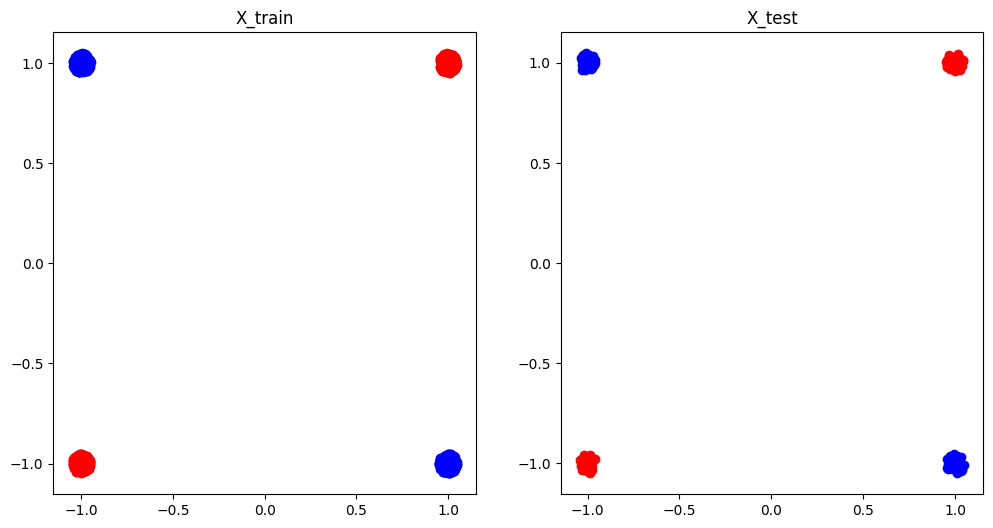

In [144]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("X_train")
plt.scatter(X_train[y_train_ravel == -1][:,0], X_train[y_train_ravel == -1][:,1], color='red')
plt.scatter(X_train[y_train_ravel == 1][:,0], X_train[y_train_ravel == 1][:,1], color='blue')

plt.subplot(1,2,2)
plt.title("X_test")
plt.scatter(X_test[y_test_ravel == -1][:,0], X_test[y_test_ravel == -1][:,1], color='red')
plt.scatter(X_test[y_test_ravel == 1][:,0], X_test[y_test_ravel == 1][:,1], color='blue')
plt.show()

In [145]:
class k_means():
    def __init__(self, n_clusters, varianza_func, inicializacion='random', metodo='por lotes', max_iters=500, eps=1e-3, learning_rate = 0.01):
        self.n_clusters = n_clusters
        self.max_iters = max_iters
        self.get_variance = varianza_func
        self.eps = eps
        self.learning_rate = learning_rate
        self.centroides = None
        self.historial = []
    
        match inicializacion:
            case 'random':
                self.func_inicializacion = self.random_sample

            case 'kmeans++':
                self.func_inicializacion = self.kmeans_plus_plus

            case 'uniform':
                self.func_inicializacion = self.random_uniform

        match metodo:
            case 'por lotes':
                self.fit_method = self.fit_lotes
            
            case 'online':
                self.fit_method = self.fit_online

    def random_sample(self, X):
        centroides = []
        for clase in range(self.n_clusters):
            # Nos quedamos con un dato aleatorio del dataset para el centroide
            idx = np.random.choice(X.shape[0])
            centroides.append(X[idx])
        return centroides

    def kmeans_plus_plus(self, X):
        N = X.shape[0]
        centroides = []

        idx = np.random.choice(N)
        centroides.append(X[idx])

        for it in range(1, self.n_clusters):
            distancia_maxima = []
            for i in range(N): # Recorro todos los datos
                d = 0
                for c in centroides: # Comparo con todos los centroides
                    d += np.linalg.norm(X[i] - c)
                distancia_maxima.append(d)
            centroides.append(X[np.argmax(distancia_maxima), :])
        
        return centroides
            
    def random_uniform(self, X):
        minimos = np.min(X, axis=0)
        maximos = np.max(X, axis=0)

        centroides = np.random.rand(self.n_clusters, X.shape[1]) * (maximos - minimos) + minimos
        return centroides


    def _recalcular_centroides(self, X, asignaciones):
        nuevos_centroides = np.zeros((self.n_clusters, X.shape[1]))

        for clase in range(self.n_clusters):
            X_clase = X[asignaciones == clase]
            if len(X_clase) > 0:
                nuevos_centroides[clase, :] = np.mean(X_clase, axis=0)
            else:
                nuevos_centroides[clase, :] = self.centroides[clase]
        
        return nuevos_centroides.tolist() # Pq quedamos en que es lista
            
    def fit(self, X):
        self.fit_method(X)

    def fit_lotes(self, X): # Va a ser X_train: N x features
        self.centroides = self.func_inicializacion(X)
        self.historial = []
        # distancias = N x K
        N = X.shape[0]
        K = self.n_clusters
        distancias = np.zeros((N,K))
        J = np.inf
        asignaciones = []
        for epoch in range(self.max_iters):
            # Paso 1 sería asignar los datos
            for clase in range(self.n_clusters):
                aux = np.linalg.norm(X - self.centroides[clase], axis=1)
                distancias[:,clase] = aux
            asignaciones = np.argmin(distancias, axis=1)

            centroides_array = np.array(self.centroides)

            # actualizar temporalmente centroides
            centroides_backup = self.centroides
            self.centroides = centroides_array

            covarianzas = self.get_variance(X, centroides_array)

            # restaurar
            self.centroides = centroides_backup

            self.historial.append({
                "centroides": centroides_array.copy(),
                "asignaciones": asignaciones.copy(),
                "covarianzas": covarianzas.copy()
            })

            J_nuevo = np.sum(distancias[np.arange(N), asignaciones]**2)
            if np.abs(J - J_nuevo) < self.eps:
                break
            J = J_nuevo

            # Paso 2 sería recalcular los centroides
            self.centroides = self._recalcular_centroides(X, asignaciones)

    def fit_online(self, X):
        self.centroides = self.func_inicializacion(X)
        N = X.shape[0]
        K = self.n_clusters
        self.historial = []
        distancias = np.zeros((N,K))
        asignaciones = []
        for clase in range(K):
            aux = np.linalg.norm(X - self.centroides[clase], axis=1)
            distancias[:,clase] = aux
        asignaciones = np.argmin(distancias, axis=1)

        for epoch in range(self.max_iters):
            centroides_prev = np.array(self.centroides).copy()

            for i in range(N):
                dato = X[i, :]
                dist_indiv = []
                
                centroides_array = np.array(self.centroides)

                # actualizar temporalmente centroides
                centroides_backup = self.centroides
                self.centroides = centroides_array

                covarianzas = self.get_variance(X, centroides_array)

                # restaurar
                self.centroides = centroides_backup

                self.historial.append({
                    "centroides": centroides_array.copy(),
                    "asignaciones": asignaciones.copy(),
                    "covarianzas": covarianzas.copy()
                })

                for clase in range(K):
                    dist_indiv.append(np.linalg.norm(dato - self.centroides[clase]))
                
                idx_ganador = np.argmin(dist_indiv)
                asignaciones[i] = idx_ganador

                self.centroides[idx_ganador] += self.learning_rate * (dato - self.centroides[idx_ganador])

            cambio = np.sum(np.linalg.norm(self.centroides - centroides_prev, axis=1))
            if cambio < self.eps:
                break

    def transform(self, X):
        asignaciones = []
        N = X.shape[0]
        K = self.n_clusters
        distancias = np.zeros((N,K))

        for clase in range(self.n_clusters):
            aux = np.linalg.norm(X - self.centroides[clase], axis=1)
            distancias[:,clase] = aux
        asignaciones = np.argmin(distancias, axis=1)

        return asignaciones

In [228]:
# lo hago aparte para no mezclar

class RBFNN():
    def __init__(self, n_clusters, inicializacion = 'random', k_means_opt = 'por lotes', variance_treatement = 'identity', activation_function = 'normal', output_activation = 'linear', learning_rate = 0.01, max_iters = 500, eps = 1e-4):
        self.n_clusters = n_clusters
        self.learning_rate = learning_rate
        self.max_iters = max_iters
        self.eps = eps
        self.historial_metric = []
        self.historial_error = []

        #a calcular
        self.centroides = None
        self.variances = None

        self.es_clasificacion = True

        if output_activation in ['linear']:
            self.es_clasificacion = False
        

        #seleccion de tratamiento de varianza
        match variance_treatement:
            case 'identity':
                self.get_variance = self._variance_identity
            
            case 'differents':
                self.get_variance = self._variance_differents
            
            case 'general':
                self.get_variance = self._variance_general


        # seleccion de funcion de activacion de las neuronas
        match activation_function:
            case 'normal':
                self.func_activation = self._normal_function
            #podriamos poner mas casos de funciones para probar

        # inicializacion
        match inicializacion:
            case 'random'|'kmeans++'|'uniform':
                self.k_means = k_means(n_clusters, self.get_variance, inicializacion, k_means_opt)
            case _:
                print("Error k_means no soporta esa inicializacion / metodo")

        match output_activation:
            case 'linear':
                self.func_output_activation = self._linear_output
                self.func_output_activation_grad = self._grad_linear
            case 'sigmoide simetrica':
                self.func_output_activation = self._sigmoide_simetrica
                self.func_output_activation_grad = self._grad_sigmoide_simetrica

    def _linear_output(self, x):
        return x
    def _grad_linear(self, x):
        return np.ones_like(x)
    
    def _sigmoide_simetrica(self, x):
        return 2 / (1 + np.exp(-x)) - 1
    
    def _grad_sigmoide_simetrica(self, x):
        y = self._sigmoide_simetrica(x)  
        return 0.5 * (1 + y) * (1 - y)
    
    def _variance_identity(self, X, centroides):
        d = X.shape[1]
        variances = np.zeros((self.n_clusters, d, d))
        
        for k in range(self.n_clusters):
            variances[k] = np.eye(d)
        
        return variances
    
    def _variance_differents(self, X, centroides):
        d = X.shape[1]
        variances = np.zeros((self.n_clusters, d, d))
        asignaciones = self.k_means.transform(X)

        for k in range(self.n_clusters):
            Xk = X[asignaciones == k]

            if len(Xk) > 0:
                sigma2 = np.mean(np.linalg.norm(Xk - centroides[k], axis=1)**2)
                variances[k] = sigma2 * np.eye(d)
            else:
                variances[k] = np.eye(d)

        return variances

    def _variance_general(self, X, centroides):
        d = X.shape[1]
        variances = np.zeros((self.n_clusters, d, d))
        asignaciones = self.k_means.transform(X)

        for k in range(self.n_clusters):
            Xk = X[asignaciones == k]

            if len(Xk) > 1:
                cov = np.cov(Xk, rowvar=False)
                variances[k] = cov + 1e-6 * np.eye(d)  # regularización
            else:
                variances[k] = np.eye(d)

        return variances        

    def _normal_function(self, distancia, varianza):
        """ distancia = ||x-c||, varianza = sigma^2"""
        return np.exp(-distancia**2 / (2 * varianza))

    def _normal_function(self, x_i, media, Sigma):
        inv_Sigma = np.linalg.pinv(Sigma)
        return np.exp(-0.5 * (x_i - media).T @ inv_Sigma @ (x_i - media))[0][0]
    
    def fit(self, X, y):
        if y.ndim == 1:
            y = y.reshape(-1, 1)
        self.n_outputs = y.shape[1]
        # entrenamiento parte 1: No supervisado
        self.k_means.fit(X) #lo creo en el constructor directamente!
        self.centroides = self.k_means.centroides
        self.variance = self.get_variance(X, self.centroides)

        #entrenamiento parte 2: supervisado
        #inicializamos los pesos aleatoriamente
        self.weights = np.random.uniform(-0.5, 0.5, size=(self.n_outputs, self.n_clusters + 1)) #para incluir al bias
        
        self.historial_metric.append(self.calculate_metric(X, y))
        self.historial_error.append(self.calculate_error(X, y))
        #metodo descenso estocastico???
        
        for epoch in range(self.max_iters):
            for i in range(X.shape[0]): #recorro todos los datos (filas)
                x_i= X[i, :].reshape(-1,1)
                #calculamos la activaciones
                phi_i = np.zeros(self.n_clusters)
                

                #recorremos cada neurona oculta y obtenemos la activacion
                for clase in range(self.n_clusters):
                    media = np.array(self.centroides[clase]).reshape(-1,1)
                    varianza = self.variance[clase] #el indice es la clase
                    phi_i[clase] = self.func_activation(x_i, media, varianza)

                #calculamos la salida de la red
                
                #calculamos el error y actualizamos los pesos
                phi_i_bias = np.concatenate(([-1], phi_i))

                v = self.weights @ phi_i_bias #salida lineal 

                salida = self.func_output_activation(v)

                #actualizacion
                error = salida - y[i,:]
                for k in range(self.n_outputs):
                    grad = error[k] * self.func_output_activation_grad(v[k]) * phi_i_bias
                    self.weights[k, :] -= self.learning_rate * grad
            error_epoca = self.calculate_error(X, y)
            print(f"Época {epoch}: {error_epoca}")
            self.historial_error.append(error_epoca)
            
            metrica_epoca = self.calculate_metric(X, y)
            self.historial_metric.append(metrica_epoca)

            if np.abs(self.historial_error[-2] - error_epoca) < 0.01:
                break

            if np.abs(self.historial_metric[-2] - metrica_epoca) < self.eps:
                break

    def transform(self, X):
        y_pred = []
        for i in range(X.shape[0]): #recorro todos los datos (filas)
            x_i= X[i, :].reshape(-1,1)
            #calculamos la activaciones
            phi_i = np.zeros(self.n_clusters)
                

            #recorremos cada neurona oculta y obtenemos la activacion
            for clase in range(self.n_clusters):
                media = np.array(self.centroides[clase]).reshape(-1,1)
                varianza = self.variance[clase] #el indice es la clase
                phi_i[clase] = self.func_activation(x_i, media, varianza)

            #calculamos la salida de la red
                
            #calculamos el error y actualizamos los pesos
            phi_i_bias = np.concatenate(([-1], phi_i))

            v = self.weights @ phi_i_bias #salida lineal 

            salida = self.func_output_activation(v)

            y_pred.append(salida)
        return np.array(y_pred)
    
    def calculate_error(self, X, y):
        y_pred = self.transform(X)
        return np.sum((y_pred - y)**2)

    def calculate_metric(self, X, y):
        metrica = 0
        y_pred = self.transform(X)
        if self.n_outputs == 1 and self.es_clasificacion:
            # Precisión
            y_pred_bool = y_pred >= 0
            y_pred_bool = y_pred_bool.astype(int)
            y_pred_bool[y_pred_bool == 0] = -1
            precision = len(np.where(y == y_pred_bool)[0])/len(y)
            metrica = precision
        
        if self.n_outputs > 1 and self.es_clasificacion:
            pred_class = np.argmax(y_pred, axis=1)
            true_class = np.argmax(y, axis=1)

            return np.mean(pred_class == true_class)

        return metrica

In [147]:
model = RBFNN(
    n_clusters=4,
    inicializacion='kmeans++', 
    k_means_opt='por lotes', 
    variance_treatement='differents', 
    activation_function='normal', 
    output_activation='sigmoide simetrica', 
    learning_rate=0.01, 
    max_iters=100, 
    eps=0.001
)

model.fit(X_train, y_train)
y_pred = model.transform(X_test)

print(model.calculate_metric(X_test, y_test))

Época 0: 763.3022926236529
Época 1: 496.67838533738154
1.0


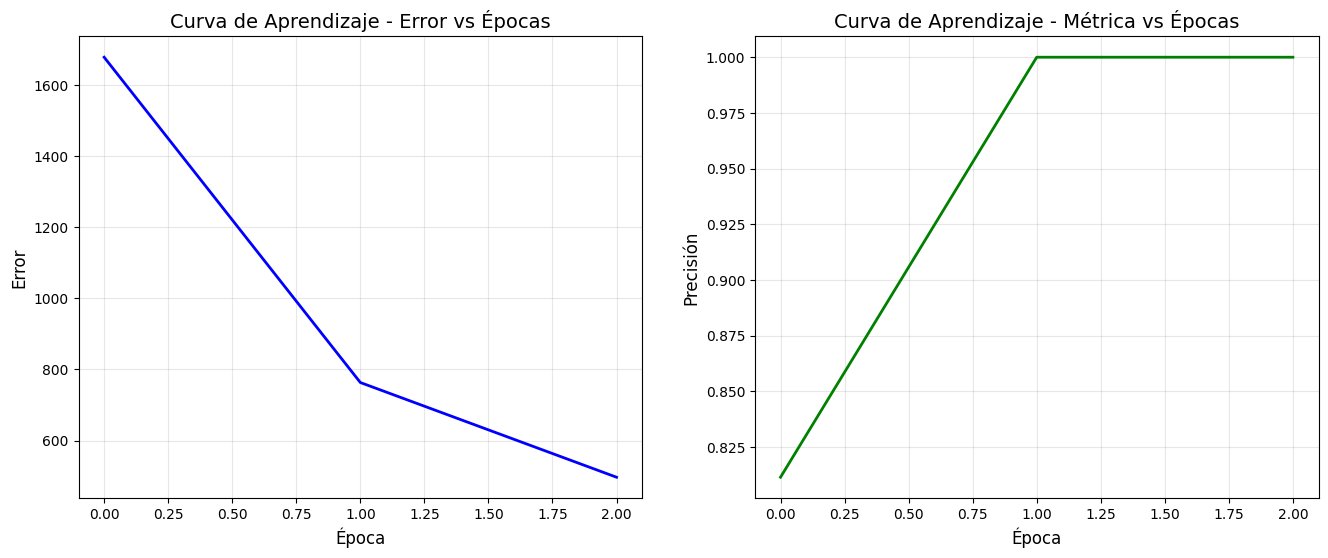

In [148]:
plt.figure(figsize=(16, 6))
plt.subplot(1,2,1)
plt.plot(model.historial_error, color='blue', linewidth=2)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('Curva de Aprendizaje - Error vs Épocas', fontsize=14)
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(model.historial_metric, color='green', linewidth=2)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Precisión', fontsize=12)
plt.title('Curva de Aprendizaje - Métrica vs Épocas', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

In [149]:
# PARA GRAFICAR LA EVOLUCIÓN DE LOS CENTROIDES
from matplotlib import animation
from IPython.display import HTML
import matplotlib.colors as mcolors
from matplotlib.patches import Ellipse

def dibujar_elipse(ax, mu, Sigma, color, n_std=2.0):
    # autovalores y autovectores
    vals, vecs = np.linalg.eigh(Sigma)

    # ordenar de mayor a menor
    order = vals.argsort()[::-1]
    vals = vals[order]
    vecs = vecs[:, order]

    # ángulo de rotación
    theta = np.degrees(np.arctan2(vecs[1,0], vecs[0,0]))

    # ejes (escala con n_std)
    width, height = 2 * n_std * np.sqrt(vals)

    ellipse = Ellipse(
        xy=mu,
        width=width,
        height=height,
        angle=theta,
        edgecolor=color,
        facecolor='none',
        linestyle='--',
        linewidth=2,
        alpha=0.7
    )

    ax.add_patch(ellipse)

def crear_animacion(variables, funcion_plot, intervalo=200, paso=1):
    fig, axs = plt.subplots(1, 1, figsize=(6, 5))

    frames_indices = range(0, len(variables), paso)

    def update(frame):
        axs.clear()
        funcion_plot(variables, frame, axs)

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=frames_indices,
        interval=intervalo,
        blit=False
    )

    plt.close()
    return HTML(anim.to_jshtml())

def plot_kmeans_frame(historial, frame, axs, X, colores):
    ax = axs

    estado = historial[frame]
    centroides = estado["centroides"]
    asignaciones = estado["asignaciones"]
    covarianzas = estado["covarianzas"]

    K = centroides.shape[0]

    # puntos
    for i in range(K):
        puntos = X[asignaciones == i]
        ax.scatter(puntos[:,0], puntos[:,1], color=colores[i], alpha=0.6)

    # centroides
    for i in range(K):
        base_color = mcolors.to_rgb(colores[i])
        darker = tuple(c * 0.7 for c in base_color)

        ax.scatter(centroides[i,0], centroides[i,1],
                   color=darker, marker="x", s=120)

    # elipses 
    for i in range(min(K, len(covarianzas))):
        dibujar_elipse(ax, centroides[i], covarianzas[i], colores[i], n_std=2)

    ax.set_title(f"Frame {frame}")
    ax.grid()

def plot_wrapper_kmeans(X, colores):
    def plot(historial, frame, axs):
        plot_kmeans_frame(historial, frame, axs, X, colores)
    return plot

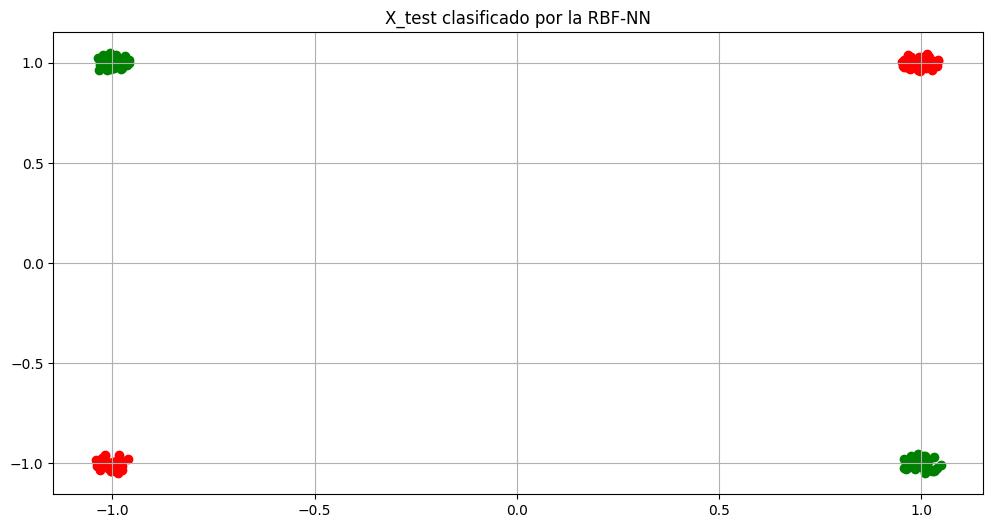

In [150]:
colores = ["red", "green", "blue", "gray", 'purple', 'cyan']
n_clusters = model.n_clusters

asignaciones = model.transform(X_test)
asignaciones = y_pred >= 0
asignaciones = asignaciones.astype(int)
asignaciones = asignaciones.ravel()
plt.figure(figsize=(12,6))
plt.title("X_test clasificado por la RBF-NN")

for i in range(n_clusters):
    plt.scatter(X_test[asignaciones == i][:,0], X_test[asignaciones == i][:,1], color=colores[i])

plt.grid()
plt.show()

In [151]:
historial = model.k_means.historial
print(len(historial))

anim = crear_animacion(
    historial,
    plot_wrapper_kmeans(X_train, colores),
    intervalo=200,
    paso = 1
)

anim

3


# Datos CONCENT

In [152]:
X_train, y_train = cargar_datos_csv(os.path.join(ruta_data, 'concent_trn.csv'))
X_test, y_test = cargar_datos_csv(os.path.join(ruta_data, 'concent_tst.csv'))
X_train, y_train, X_test, y_test = np.array(X_train), np.array(y_train), np.array(X_test), np.array(y_test)

y_train_ravel = y_train.ravel()
y_test_ravel = y_test.ravel()

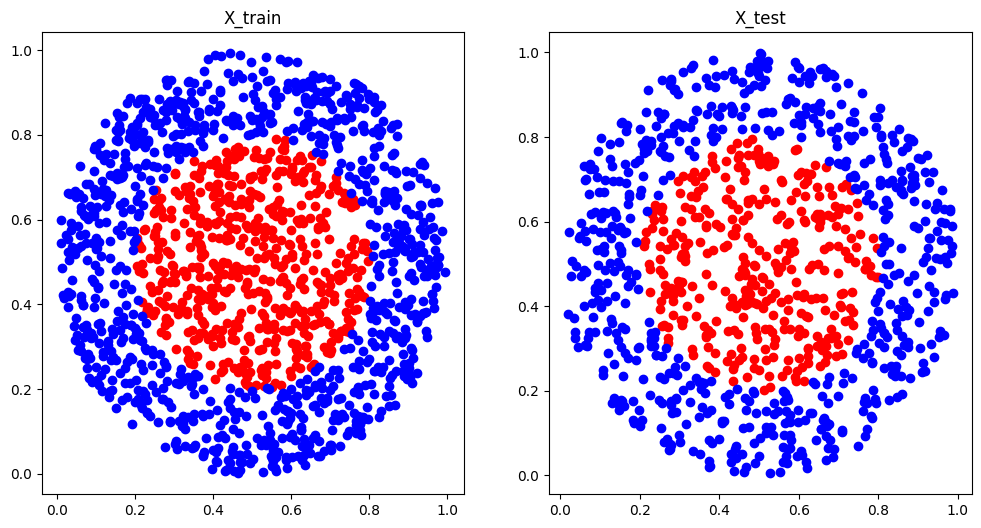

In [153]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("X_train")
plt.scatter(X_train[y_train_ravel == -1][:,0], X_train[y_train_ravel == -1][:,1], color='red')
plt.scatter(X_train[y_train_ravel == 1][:,0], X_train[y_train_ravel == 1][:,1], color='blue')

plt.subplot(1,2,2)
plt.title("X_test")
plt.scatter(X_test[y_test_ravel == -1][:,0], X_test[y_test_ravel == -1][:,1], color='red')
plt.scatter(X_test[y_test_ravel == 1][:,0], X_test[y_test_ravel == 1][:,1], color='blue')
plt.show()

In [154]:
model = RBFNN(
    n_clusters=1,
    inicializacion='kmeans++', 
    k_means_opt='por lotes', 
    variance_treatement='differents', 
    activation_function='normal', 
    output_activation='sigmoide simetrica', 
    learning_rate=0.01, 
    max_iters=100, 
    eps=0.001
)

model.fit(X_train, y_train)
y_pred = model.transform(X_test)

print(model.calculate_metric(X_test, y_test))

Época 0: 1328.9540749545145
Época 1: 1177.9130969794496
Época 2: 1052.493474526074
Época 3: 949.784224689865
Época 4: 865.8638167942138
Época 5: 796.9670017466083
Época 6: 739.9222807032347
Época 7: 692.2088705948759
Época 8: 651.8739560989792
Época 9: 617.4184282487549
Época 10: 587.6916209904523
Época 11: 561.8060682674507
Época 12: 539.0721756912278
Época 13: 518.9493707993781
Época 14: 501.0099208233556
0.98


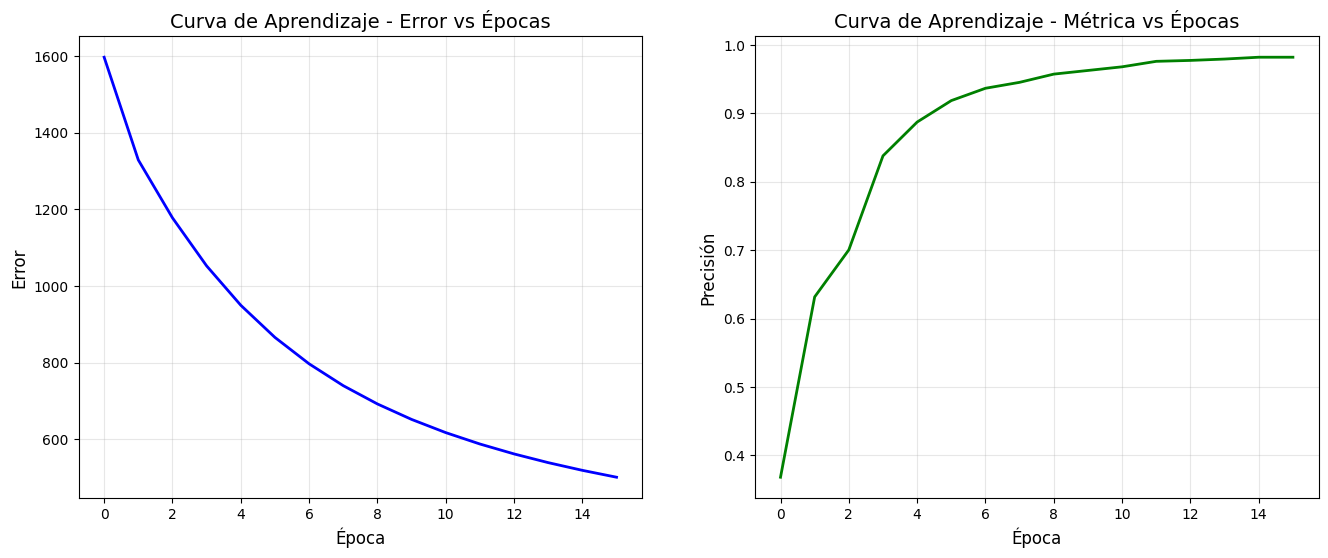

In [155]:
plt.figure(figsize=(16, 6))
plt.subplot(1,2,1)
plt.plot(model.historial_error, color='blue', linewidth=2)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('Curva de Aprendizaje - Error vs Épocas', fontsize=14)
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(model.historial_metric, color='green', linewidth=2)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Precisión', fontsize=12)
plt.title('Curva de Aprendizaje - Métrica vs Épocas', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

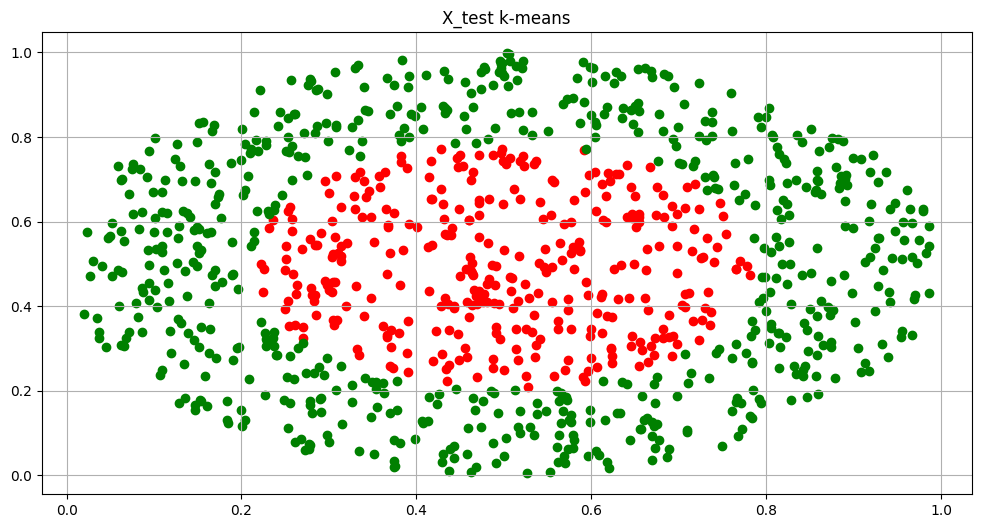

In [156]:
n_clusters = model.n_clusters
if n_clusters == 1:
    n_clusters = 2

asignaciones = model.transform(X_test)
asignaciones = y_pred >= 0
asignaciones = asignaciones.astype(int)
asignaciones = asignaciones.ravel()
plt.figure(figsize=(12,6))
plt.title("X_test k-means")

for i in range(n_clusters):
    plt.scatter(X_test[asignaciones == i][:,0], X_test[asignaciones == i][:,1], color=colores[i])

plt.grid()
plt.show()

In [157]:
historial = model.k_means.historial
print(len(historial))

anim = crear_animacion(
    historial,
    plot_wrapper_kmeans(X_train, colores),
    intervalo=200,
    paso = 1
)

anim

3


In [158]:
"""
n_clases = 4
colores = ["red", "green", "blue", "gray"]
K_MEANS = k_means(n_clases, 'uniform')

K_MEANS.fit(X_train)
asignaciones = K_MEANS.transform(X_test)
asignaciones = asignaciones.ravel()
plt.figure(figsize=(12,6))
plt.title("X_test k-means")

for i in range(n_clases):
    plt.scatter(X_test[asignaciones == i][:,0], X_test[asignaciones == i][:,1], color=colores[i])

plt.grid()
plt.show()
"""

'\nn_clases = 4\ncolores = ["red", "green", "blue", "gray"]\nK_MEANS = k_means(n_clases, \'uniform\')\n\nK_MEANS.fit(X_train)\nasignaciones = K_MEANS.transform(X_test)\nasignaciones = asignaciones.ravel()\nplt.figure(figsize=(12,6))\nplt.title("X_test k-means")\n\nfor i in range(n_clases):\n    plt.scatter(X_test[asignaciones == i][:,0], X_test[asignaciones == i][:,1], color=colores[i])\n\nplt.grid()\nplt.show()\n'

# Datos Iris

In [159]:
X_train, y_train = cargar_datos_csv(os.path.join(ruta_data, 'iris81_trn.csv'), salidas = 3)
X_test, y_test = cargar_datos_csv(os.path.join(ruta_data, 'iris81_tst.csv'), salidas = 3)
X_train, y_train, X_test, y_test = np.array(X_train), np.array(y_train), np.array(X_test), np.array(y_test)


In [160]:
model = RBFNN(
    n_clusters=4,
    inicializacion='kmeans++', 
    k_means_opt='por lotes', 
    variance_treatement='differents', 
    activation_function='normal', 
    output_activation='sigmoide simetrica', 
    learning_rate=0.01, 
    max_iters=100, 
    eps=0.001
)

model.fit(X_train, y_train)
y_pred = model.transform(X_test)

print(model.calculate_metric(X_test, y_test))

Época 0: 286.0297528521824
Época 1: 257.1381354903257
Época 2: 237.24241404697872
Época 3: 222.16598215690667
Época 4: 209.83682857175103
Época 5: 199.25015098831713
0.972972972972973


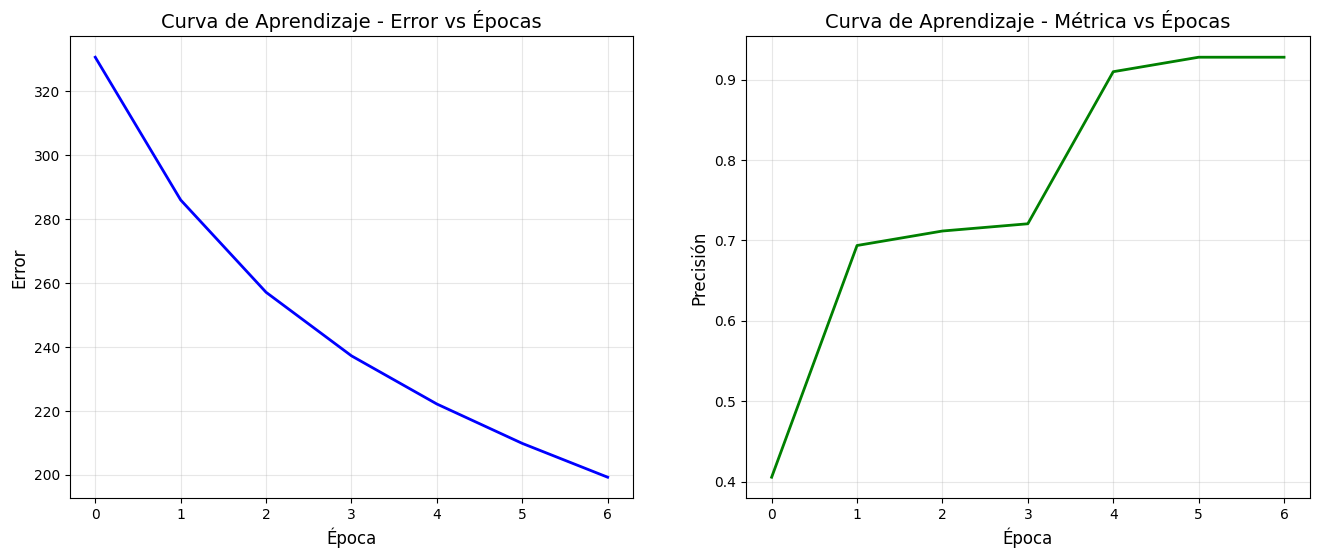

In [161]:
plt.figure(figsize=(16, 6))
plt.subplot(1,2,1)
plt.plot(model.historial_error, color='blue', linewidth=2)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('Curva de Aprendizaje - Error vs Épocas', fontsize=14)
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(model.historial_metric, color='green', linewidth=2)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Precisión', fontsize=12)
plt.title('Curva de Aprendizaje - Métrica vs Épocas', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

# Datos MERVAL

In [162]:
from datetime import datetime

In [194]:
import json

def guardar_resultado_json(path, model, error):
    resultado = {
        "n_clusters": model.n_clusters,
        "inicializacion": model.k_means.func_inicializacion.__name__,
        "k_means_opt": model.k_means.fit_method.__name__,
        "variance_treatement": model.get_variance.__name__,
        "activation_function": model.func_activation.__name__,
        "output_activation": model.func_output_activation.__name__,
        "learning_rate": model.learning_rate,
        "max_iters": model.max_iters,
        "eps": model.eps,
        "error": float(error)
    }

    with open(path, "a", encoding="utf-8") as f:
        f.write(json.dumps(resultado) + "\n")

In [190]:
def train_test_split_temporal(data, test_size=0.2, window_size=5):
    """
    data: array (N, d)  -> d puede ser 1 (solo valor) o más columnas
    test_size: proporción para test
    window_size: cantidad de pasos consecutivos por fila

    retorna:
        X_train, X_test
    """
    window_size += 1

    N = data.shape[0]
    idx_split = int(N * (1 - test_size))

    train = data[:idx_split]
    test = data[idx_split:]

    # DATASET TRAIN
    N = train.shape[0]
    X_train, y_train = [], []

    for i in range(N - window_size):
        X_train.append(train[i:i+window_size-1])
        y_train.append(train[i+window_size])

    X_train, y_train = np.array(X_train), np.array(y_train)
    
    # DATASET TEST
    N = test.shape[0]
    X_test, y_test = [], []

    for i in range(N - window_size):
        X_test.append(test[i:i+window_size-1])
        y_test.append(test[i+window_size])

    X_test, y_test = np.array(X_test), np.array(y_test)

    return X_train, y_train, X_test, y_test

In [265]:
merval = cargar_datos_csv(os.path.join(ruta_data, 'MERVAL2426.csv'), salidas = 0)

valores = np.array(merval[:-1])[0,:,:]

# ordenar por fecha
valores = valores[valores[:,0].argsort()][:,1]

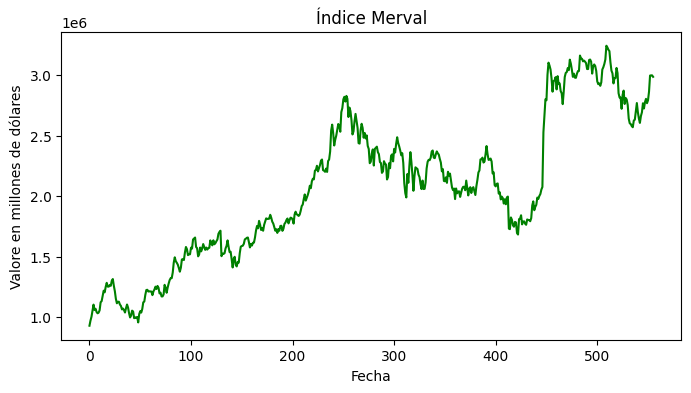

In [266]:
plt.figure(figsize=(8,4))
plt.title("Índice Merval")
plt.xlabel("Fecha")
plt.ylabel("Valore en millones de dólares")
plt.plot(valores, color='green')
plt.show()

In [273]:
X_train, y_train, X_test, y_test = train_test_split_temporal(valores, test_size=0.2, window_size=3)

X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)
X_std[X_std == 0] = 1

X_train = (X_train - X_mean) / X_std
X_test  = (X_test  - X_mean) / X_std


y_mean = np.mean(y_train, axis=0)
y_std = np.std(y_train, axis=0)
if y_std == 0:
    y_std = 1

y_train = (y_train - y_mean) / y_std
y_test  = (y_test  - y_mean) / y_std

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(440, 3) (440,)
(108, 3) (108,)


In [274]:
model = RBFNN(
    n_clusters=10,
    inicializacion='kmeans++', 
    k_means_opt='por lotes', 
    variance_treatement='identity', 
    activation_function='normal', 
    output_activation='linear', 
    learning_rate=0.01, 
    max_iters=100, 
    eps=-0.001
)

model.fit(X_train, y_train)
y_pred = model.transform(X_test)

y_pred_real = y_pred * y_std + y_mean
y_test_real = y_test * y_std + y_mean

Época 0: 118.15492831150667
Época 1: 39.761612618862976
Época 2: 30.35069629641212
Época 3: 27.85487744167271
Época 4: 26.695029318912926
Época 5: 26.002137636796412
Época 6: 25.506360652905553
Época 7: 25.103366425662504
Época 8: 24.75140102081636
Época 9: 24.432936633727948
Época 10: 24.139771655908778
Época 11: 23.867371406391744
Época 12: 23.61274601043566
Época 13: 23.37365044761514
Época 14: 23.148272545816017
Época 15: 22.935100219651282
Época 16: 22.732855012260323
Época 17: 22.540451022857788
Época 18: 22.356964546950863
Época 19: 22.181609211224057
Época 20: 22.013714729314216
Época 21: 21.852708548029923
Época 22: 21.698100019960872
Época 23: 21.549466842238374
Época 24: 21.406443524993875
Época 25: 21.268711658919564
Época 26: 21.135991758215567
Época 27: 21.008036467157652
Época 28: 20.8846249348672
Época 29: 20.765558181865323
Época 30: 20.65065530200059
Época 31: 20.539750363104485
Época 32: 20.43268988843829
Época 33: 20.329330818164724
Época 34: 20.229538865477878
Époc

In [275]:
error = model.calculate_error(X_test, y_test)

guardar_resultado_json("resultados_merval.csv", model, error)

In [276]:
print(model.calculate_error(X_test, y_test))

23950.249334099703


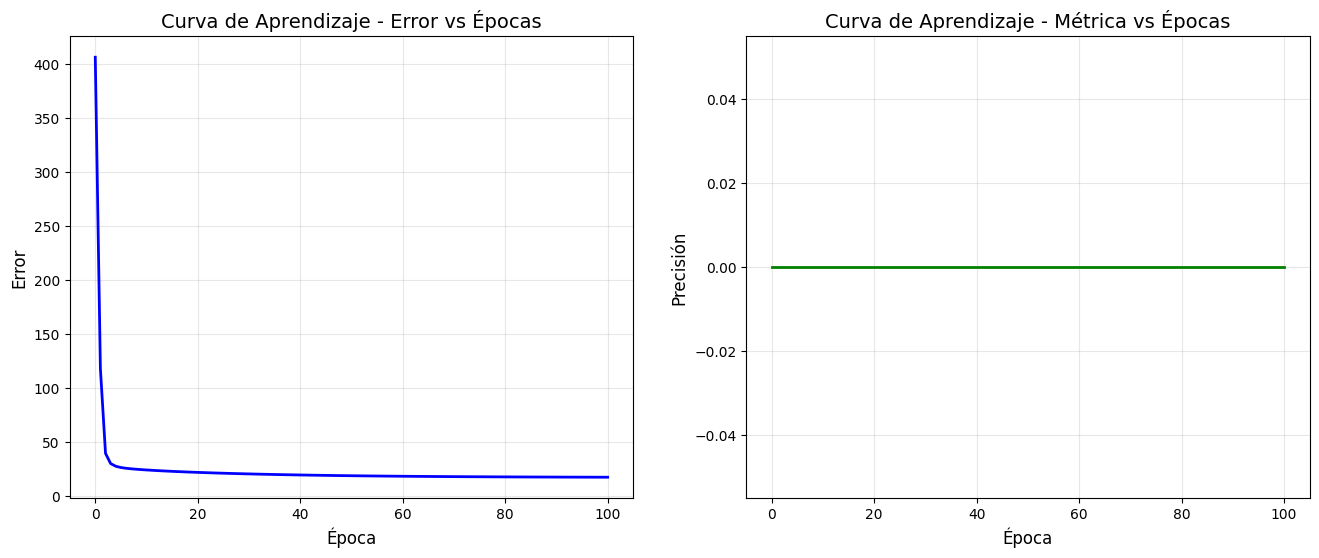

In [277]:
plt.figure(figsize=(16, 6))
plt.subplot(1,2,1)
plt.plot(model.historial_error, color='blue', linewidth=2)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Error', fontsize=12)
plt.title('Curva de Aprendizaje - Error vs Épocas', fontsize=14)
plt.grid(True, alpha=0.3)

plt.subplot(1,2,2)
plt.plot(model.historial_metric, color='green', linewidth=2)
plt.xlabel('Época', fontsize=12)
plt.ylabel('Precisión', fontsize=12)
plt.title('Curva de Aprendizaje - Métrica vs Épocas', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

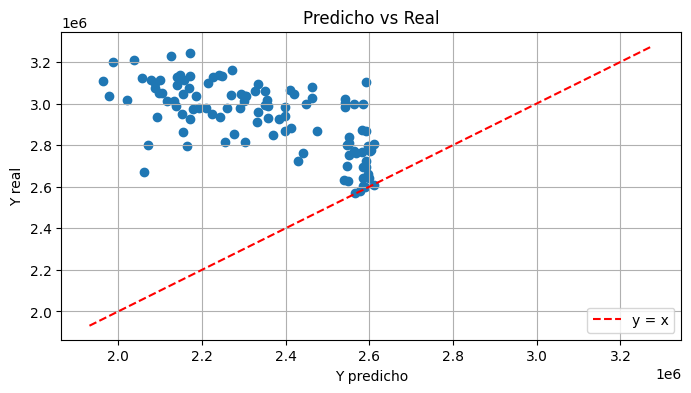

In [278]:
plt.figure(figsize=(8,4))
plt.xlabel("Y predicho")
plt.ylabel("Y real")
plt.title("Predicho vs Real")

plt.scatter(y_pred_real, y_test_real)

# recta y = x
min_val = min(plt.xlim()[0], plt.ylim()[0])
max_val = max(plt.xlim()[1], plt.ylim()[1])
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='y = x')

plt.legend()
plt.grid()
plt.show()